# Amazon Delivery Dataset


---

**Validação e Seleção de Modelo - Amazon Last-Mile**

O objetivo desta seção é realizar uma validação de diferentes modelos de Machine Learning para a tarefa de regressão, visando identificar o algoritmo que oferece o melhor equilíbrio entre desempenho preditivo e robustez para estimar o **order_cicle_time**. Serão comparados quatro modelos (Árvore de Regressão, LightGBM, CatBoost e RandomForest) usando métricas de erro padronizadas.


**Target**

* Predição do **order_cicle_time** (tempo total do pedido).
* Modelo Baseline: Árvore de Regressão (TreeDecisionRegressor do **Sklearn**).
* **OTD:** Entregas realizadas no SLA (tempo mínimo de 2 horas). Medido desde a entrada do pedido no sistema até o destino final do cliente.

---

**Separação dos dados em treino e teste**

* Transformação logarítima do target para redução de heterocedasticidade.
* Divisão dos dados em conjuntos de **Treino (80%)** e **Teste (20%)**.


---

**Treinamento e otimização de modelo**
* Para cada algoritmo (Baseline, LightGBM, CatBoost, RandomForest), será seguido um fluxo de etapas:

    **Construção do Pipeline**
    * Pipeline com clipagem de outliers numéricos, discretização de valores em categorias e encoding de dados categóricos (exceto CatBoost que realiza encoding internamente).

    **Cross-Validation com GridSearchCV**
    * Divisão dos dados com KFold (5).

    **Ajuste de HiperParâmetros com HalvingRandomCV**

    * Construção de Run no MLFlow para persistência do modelo.
    * Divisão dos dados com KFold (5).
    * Otimização do tempo de busca de hiperparâmetros com teste de um grande número de combinações em subconjuntos de dados (ou com menos recursos), descartando as piores iterações rapidamente.

---

**Comparação entre Modelos**

* Análise gráfica da `learning curve` modelos com hiperparâmetros ajustados.
* Dataset com métricas de treino e teste, tempo de performance de treino e teste, e hiperparâmetros.
* Link de acesso ao painel MLFlow UI.
* Modelo em produção no MLFlow.
* Persistência local do modelo.


---

**Winner: Análise Gráfica**
* Gráfico Árvore para entendimento do modelo.
* `SHAP Value`: Gráfico Bar Plot para análise da importância global das features.
* `SHAP Value`: Gráfico Beeswarm para análise do impacto individual dos valores das features na decisão do modelo.

    **Análise de Resíduos e Definição de Políticas para ações corretivas**

    * Gráfico Real x Resíduo: Uso da distribuição de erros para estabelecer margem de erro de negócio (SLA) e ações corretivas operacionais.

---

In [3]:
# carregamento de bibliotecas
import sys
import os
from dotenv import load_dotenv
import time
import pandas as pd
import dagshub
import mlflow
from datetime import datetime
# Adiciona a pasta raiz do projeto (onde está a pasta src) ao sys.path
sys.path.append(os.path.abspath(os.path.join("..")))
from src.data.load_data import *
from src.config.logging_config import setup_logging
from src.visualization.interactive_plot import *
from src.visualization.static_plot import *
from src.modeling.train import *
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import lightgbm as lgb
from src.modeling.train import *
from sklearn.model_selection import KFold
from src.modeling.plot import *
import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
from src.visualization.static_plot import *
import joblib
from mlflow.pyfunc import load_model as load_pyfunc_model
from mlflow.tracking import MlflowClient

%load_ext autoreload
%autoreload 2


In [2]:
# carregamento das variáveis de ambiente
load_dotenv()

True

In [3]:
# variáveis de ambiente
DAGSHUB_USERNAME = os.getenv("DAGSHUB_USERNAME")
DAGSHUB_REPO = os.getenv("REPO_NAME")
DAGSHUB_TOKEN = os.getenv("DAGSHUB_TOKEN")
MLFLOW_TRACKING_URI = os.getenv('MLFLOW_TRACKING_URI')

In [4]:
# conexão com mlflow no dagshub
try:
    dagshub.init(
    repo_owner=DAGSHUB_USERNAME, 
    repo_name=DAGSHUB_REPO,
    mlflow=True
)
    print("Conexão MLflow com Dagshub configurada com sucesso.")

except Exception as e:
    # Se houver erro, pode ser um problema de Token ou rede.
    print(f"Erro ao inicializar Dagshub/MLflow: {e}")
    # Você pode querer levantar o erro aqui para interromper
    # raise e



Accessing as projeto5mlet

Initialized MLflow to track repo "projeto5mlet/amazon_last_mile_delivery"

Repository projeto5mlet/amazon_last_mile_delivery initialized!

Conexão MLflow com Dagshub configurada com sucesso.


In [ ]:
# construção do experimento no mlflow
EXPERIMENT_NAME = "AMAZON_LAST_MILE_DELIVERY"
mlflow.set_experiment(EXPERIMENT_NAME)

In [6]:
# configurações de logging
logger = setup_logging()

In [10]:
# carregamento dos dados
tbl_amazon_dlv = carregar_dataset('../data/processed/amazon_delivery_processed.csv',sep=',')

In [8]:
# visualização do dataset
tbl_amazon_dlv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40109 entries, 0 to 40108
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Agent_Age            40109 non-null  int64  
 1   Agent_Rating         40109 non-null  float64
 2   Weather              40109 non-null  object 
 3   Traffic              40109 non-null  object 
 4   Vehicle              40109 non-null  object 
 5   Area                 40109 non-null  object 
 6   pickup_duration      40109 non-null  int64  
 7   dist_gte_10          40109 non-null  int64  
 8   month                40109 non-null  int64  
 9   holiday              40109 non-null  int64  
 10  weekend              40109 non-null  int64  
 11  day_sin              40109 non-null  float64
 12  day_cos              40109 non-null  float64
 13  month_sin            40109 non-null  float64
 14  month_cos            40109 non-null  float64
 15  delivery_distance    40109 non-null 

# Separacao dos dados em treinamento e teste
Selecionamos as colunas mais alinhadas com uma execução de performance mais generalista do modelo.<br>
Esse procedimento ocorre após looping de treino e validação, onde as features atuais reduzem o nível de overfitting antes da etapa de ajuste de hiperparâmetros.<br>
`pickup_duration` gera data leakage por ser um valor integrante do target.<br>
`holiday` e `weekend` não apresentam muita capacidade preditiva.<br>
`Traffic` é substituída pela coluna `jam_or_high_traffic`.<br>
`is_sunny_weather` é substituída pela coluna `Weather` que receberá o encoding dos dados.
Para redução de *heterocedasticidade* aplicamos uma transformação logarítmica ao target antes da etapa de separação dos dados.
Essa transformação não considera estatísticas ao tratamento, mantendo o controle de data leakage. 


In [11]:
# separação dos dados
X = tbl_amazon_dlv.drop(['month', 'holiday', 'pickup_duration', 'order_cicle_time','Traffic', 'weekend','is_sunny_weather',
        'day_sin', 'day_cos', 'month_sin', 'month_cos',], axis=1)
y = np.log(tbl_amazon_dlv['order_cicle_time'])

In [12]:
# separação dos dados em treino e teste
X_treino, X_teste, y_treino, y_teste = separar_dados_treino_teste(X=X, y=y, teste_size=0.2, random_state=42)

In [13]:
# definição das colunas categóricas e numéricas
colunas_categoricas = ['Vehicle','Area','Weather']
colunas_numericas = [ 
       'delivery_distance',]

colunas_discretizacao = [
    
     'Agent_Rating','Agent_Age',
]


# Baseline: Decision Tree Regressor<br>
Pipeline com Imputer para prevenção de valores nulos, Clipagem de outliers para valores numéricos, Discretização para colunas numéricas selecionadas e Encoding para colunas categóricas. <br>
Árvore genérica com alto overfitting mesmo com cross validação. <br>
Treino: R2 Score: 0.9995<br>
Teste: R2 Score: 0.6434<br>

In [12]:
# construção do pipeline com o pré-processamento
model_baseline = criar_pipeline(colunas_categoricas=colunas_categoricas, colunas_numericas=colunas_numericas, colunas_discretizacao=colunas_discretizacao, 
                          modelo=DecisionTreeRegressor())

2025-10-04 00:59:38,262 | INFO | src.modeling.train | Iniciando construção do pipeline de pré-processamento.
2025-10-04 00:59:38,288 | INFO | src.modeling.train | Pipeline de pré-processamento construído com sucesso.Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_features',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Vehicle', 'Area',
                                                   'Weather']),
              

In [13]:
# ajuste e treino do modelo
param_grid = {}
grid_baseline = gerar_grid_search_cv(pipeline=model_baseline,param_grid=param_grid, verbose=1,)
grid_baseline.fit(X_treino, y_treino)
grid_baseline.score(X_treino, y_treino)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


0.9995913290010188

In [14]:
# previsão do modelo e resultado do teste
y_pred_baseline_grid = grid_baseline.predict(X_teste)
gerar_metricas(y_teste, y_pred_baseline_grid)


2025-10-04 00:59:39,704 | INFO | src.modeling.train | MAE: 0.2080
2025-10-04 00:59:39,705 | INFO | src.modeling.train | MSE: 0.0771
2025-10-04 00:59:39,705 | INFO | src.modeling.train | RMSE: 0.2777
2025-10-04 00:59:39,705 | INFO | src.modeling.train | R2 Score: 0.6429


(0.208034067140689,
 0.07714244287393912,
 0.27774528416147615,
 0.6428940759795418)

## Ajuste de hiper-parâmetro do modelo
Árvore genérica com baixa capacidade de precisão para redução de overfitting, diagnóstico rápido e desempenho base para ser superado pelos demais modelos.<br>
Profundidade, Quantidade de splits e volume de amostras testados para reduzir a especialização da árvore.<br>
Treino: R2 Score: 0.8183<br>
Teste: R2 Score: 0.8136<br>

In [15]:
# variáveis mlflow
MODELO_NOME = "DecisionTreeRegressor_Baseline_HalvingSearch"
RUN_NAME = f"{MODELO_NOME}_{datetime.now().strftime('%Y%m%d_%H%M')}"

In [ ]:
# ajuste de hiper-parâmetros do halving_search_cv e construção da run
mlflow.start_run(run_name=RUN_NAME)

param_grid = {

'model__criterion': ['squared_error', 'friedman_mse', 'absolute_error'],
    'model__max_depth': [3, 5, 8, 12, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}
    
start_time = time.time()
    
halving_baseline = gerar_halving_random_search_cv(pipeline=model_baseline,param_grid=param_grid, verbose=1)
halving_baseline.fit(X_treino, y_treino)
halving_baseline.score(X_treino, y_treino)

end_time = time.time()
predict_time_s = end_time - start_time

In [ ]:
# persistência do modelo
mlflow.sklearn.log_model(
        sk_model=halving_baseline, 
        artifact_path="baseline_decision_tree_model", 
        registered_model_name="Baseline_Decision_Tree_Ajustado",
        input_example=X_treino.head(1)
    )

In [18]:
# previsão do modelo e resultado do treino
y_pred_baseline = halving_baseline.predict(X_treino)
mae_t_bsl,mse_t_bsl,rmse_t_bsl,r2_t_bsl=gerar_metricas(y_true=y_treino, y_pred=y_pred_baseline)


2025-10-04 01:00:19,324 | INFO | src.modeling.train | MAE: 0.1552
2025-10-04 01:00:19,325 | INFO | src.modeling.train | MSE: 0.0397
2025-10-04 01:00:19,325 | INFO | src.modeling.train | RMSE: 0.1993
2025-10-04 01:00:19,326 | INFO | src.modeling.train | R2 Score: 0.8182


In [19]:
# previsão do modelo e resultado do teste
start_time = time.time()
y_pred_baseline_halving = halving_baseline.predict(X_teste)
end_time = time.time()
predict_time_p = end_time - start_time
mae_p_bsl,mse_p_bsl,rmse_p_bsl,r2_p_bsl = gerar_metricas(y_true=y_teste, y_pred=y_pred_baseline_halving)


2025-10-04 01:00:19,587 | INFO | src.modeling.train | MAE: 0.1563
2025-10-04 01:00:19,588 | INFO | src.modeling.train | MSE: 0.0402
2025-10-04 01:00:19,589 | INFO | src.modeling.train | RMSE: 0.2004
2025-10-04 01:00:19,590 | INFO | src.modeling.train | R2 Score: 0.8140


In [20]:
# coleta das métricas para comparativo entre modelos
metricas_baseline_halving = coletar_metricas(model_name='Baseline_Halving_Arv_Decisao',
                                            metricas_treino={'MAE': mae_t_bsl,'MSE': mse_t_bsl,'RMSE': rmse_t_bsl,'R2_Score': r2_t_bsl}, 
                                            metricas_teste={'MAE': mae_p_bsl,'MSE': mse_p_bsl,'RMSE': rmse_p_bsl,'R2_Score': r2_p_bsl}, 
                                             tmp_execucao_treino=predict_time_s, 
                                             tmp_execucao_predicao=predict_time_p,
                                             params=halving_baseline.best_params_)


# registro de hiperparâmetros
if 'Hiperparametros' in metricas_baseline_halving:
    for key, value in metricas_baseline_halving['Hiperparametros'].items():
        clean_key = key.replace('__', '_')
        mlflow.log_param(f"param_{clean_key}", value)


metricas_baseline_halving

{'Modelo': 'Baseline_Halving_Arv_Decisao',
 'R2_Teste': 0.814036409610784,
 'MAE_Teste': 0.15625802678506975,
 'MSE_Teste': 0.0401720741194169,
 'RMSE_Teste': 0.2004297236425199,
 'R2_Treino': 0.8182025184096166,
 'MAE_Treino': 0.15520415807474003,
 'MSE_Treino': 0.03972267961940285,
 'RMSE_Treino': 0.19930549319926646,
 'Tempo_Treino_Segundos': 27.14491295814514,
 'Tempo_Predicao_Segundos': 0.012034893035888672,
 'Hiperparametros': {'model__min_samples_split': 5,
  'model__min_samples_leaf': 4,
  'model__max_depth': 8,
  'model__criterion': 'squared_error'}}

In [21]:
# registro de métricas
for key, value in metricas_baseline_halving.items():
    if key not in ['Modelo', 'Hiperparametros']:
        mlflow.log_metric(key, value)

In [ ]:
# comparação da melhoria de resultado do baseline com ajuste de hiper-paramâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_curva_aprendizagem(estimator=grid_baseline.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem Baseline_Arvore_Decisao' , ax=ax[0])
grafico_curva_aprendizagem(estimator=halving_baseline.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem Baseline_Arvore_Decisao_Ajustada', ax=ax[1])

fig.savefig('../reports/figures/models/curva_aprendizagem_baseline.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/curva_aprendizagem_baseline.png', 
    artifact_path="curva_aprendizagem_baseline_halving_Decision_Tree_Regressor"
)

In [23]:
# dataset para persistir resultados do grid_baseline
dataset_validacao_grid_baseline= pd.DataFrame()
dataset_validacao_grid_baseline['y_true'] = y_teste
dataset_validacao_grid_baseline['y_pred'] = y_pred_baseline_grid
dataset_validacao_grid_baseline['res'] =  y_teste - y_pred_baseline_grid

In [24]:
# dataset para persistir resultados do halving_random_search
dataset_validacao_baseline_halving = pd.DataFrame()
dataset_validacao_baseline_halving['y_true'] = y_teste
dataset_validacao_baseline_halving['y_pred'] = y_pred_baseline_halving
dataset_validacao_baseline_halving['res'] =  y_teste - y_pred_baseline_halving

Apresenta uma melhoria na distribuição dos resíduos após o ajuste de hiperparâmetros, porém o efeito da clipagem não é tão eficiente para valores extremos menores, apresentando alta dispersão, onde se esperava pouca dispersão.<br>
Distribuição com uma range (-0.75 a 1.)

In [ ]:
# comparação da melhoria de resultado do gráfico de resíduo do modelo do baseline com ajuste de hiper-paramâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_dispersao(df=dataset_validacao_grid_baseline, y=dataset_validacao_grid_baseline['res'],
                          x=dataset_validacao_grid_baseline['y_pred'],
                          titulo='Dispersão Baseline (Resíduo x Valor Previsto)', ylabel='Resíduos', xlabel='Valor Previsto',res=True,ax=ax[0])
grafico_dispersao(df=dataset_validacao_baseline_halving, y=dataset_validacao_baseline_halving['res'],
                          x=dataset_validacao_baseline_halving['y_pred'],
                          titulo='Dispersão Baseline (Resíduo x Valor Previsto) Ajustado', ylabel='Resíduos', xlabel='Valor Previsto',res=True,ax=ax[1])

fig.savefig('../reports/figures/models/dispersao_residuo_baseline.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/dispersao_residuo_baseline.png', 
    artifact_path="dispersao_residuo_baseline_halving_Decision_Tree_Regressor"
)

In [ ]:
# comparação da melhoria de resultado do gráfico do resultado de previsão do modelo baseline com ajuste de hiper-parâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_dispersao(df=dataset_validacao_grid_baseline, y=dataset_validacao_grid_baseline['y_true'],
                          x=dataset_validacao_grid_baseline['y_pred'],
                          titulo='Dispersão Baseline (Valor Real x Valor Previsto)', ylabel='Valor Real', xlabel='Valor Previsto', regr=True, ax=ax[0])
grafico_dispersao(df=dataset_validacao_baseline_halving, y=dataset_validacao_baseline_halving['y_true'],
                          x=dataset_validacao_baseline_halving['y_pred'],
                          titulo='Dispersão Baseline (Valor Real x Valor Previsto) Ajustado', ylabel='Valor Real', xlabel='Valor Previsto', regr=True, ax=ax[1])

fig.savefig('../reports/figures/models/dispersao_real_previsto_baseline.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/dispersao_real_previsto_baseline.png', 
    artifact_path="dispersao_real_previsto_baseline_halving_Decision_Tree_Regressor"
)

In [ ]:
# gráfico histograma dos resíduos
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_histograma(dataset_validacao_grid_baseline, feature='res', titulo='Gráfico Histograma Baseline Resíduo', ax=ax[0],)
grafico_histograma(dataset_validacao_baseline_halving, feature='res', titulo='Gráfico Histograma Baseline Resíduo Ajustado', ax=ax[1])
fig.savefig('../reports/figures/models/histograma_residuo_baseline.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/histograma_residuo_baseline.png', 
    artifact_path="histograma_residuo_baseline_halving_Decision_Tree_Regressor"
)

In [28]:
# encerramento da run
mlflow.end_run()

🏃 View run DecisionTreeRegressor_Baseline_HalvingSearch_20251004_0059 at: https://dagshub.com/projeto5mlet/amazon_last_mile_delivery.mlflow/#/experiments/0/runs/dd8048a996234a2c9844b5d772687cbd
🧪 View experiment at: https://dagshub.com/projeto5mlet/amazon_last_mile_delivery.mlflow/#/experiments/0


# LightGBM
Pipeline com Imputer para prevenção de valores nulos, Clipagem de outliers para valores numéricos, Discretização para colunas numéricas selecionadas e Encoding para colunas categóricas. <br>
Árvore genérica com alta robustez e performance generalista causada pela transformação do target.<br>
Treino: R2 Score: 0.8375<br>
Teste: R2 Score: 0.8283<br>

In [15]:
# construção do pipeline com o pré-processamento
model_lightgbm = criar_pipeline(colunas_categoricas=colunas_categoricas, colunas_numericas=colunas_numericas, colunas_discretizacao= colunas_discretizacao,
                          modelo=lgb.LGBMRegressor(),)



In [ ]:
# ajuste e treino do modelo
param_grid = {}
grid_lgbm = gerar_grid_search_cv(pipeline=model_lightgbm,param_grid=param_grid, verbose=1,)
grid_lgbm.fit(X_treino, y_treino)
grid_lgbm.score(X_treino, y_treino)


In [31]:
# previsão do modelo e resultado do teste sem 
y_pred_lbg = grid_lgbm.predict(X_teste)
gerar_metricas(y_true=y_teste, y_pred=y_pred_lbg)


2025-10-04 01:00:44,591 | INFO | src.modeling.train | MAE: 0.1505
2025-10-04 01:00:44,592 | INFO | src.modeling.train | MSE: 0.0371
2025-10-04 01:00:44,592 | INFO | src.modeling.train | RMSE: 0.1926
2025-10-04 01:00:44,593 | INFO | src.modeling.train | R2 Score: 0.8283


(0.1505106472480918,
 0.03708845780583839,
 0.19258363846868817,
 0.8283110113988618)

## Ajuste de hiper-parâmetro do modelo
Árvore genérica com alta performance com controle de regularização (`min_child_samples, colsample_bytree, reg_lambda`) para garantir robustez, redução de overfitting, velocidade de previsão e potencial detalhamento de decisão(`num_leaves`).<br>
Treino: R2 Score: 0.8338<br>
Teste: R2 Score: 0.8285<br>

In [32]:
# variáveis mlflow
MODELO_NOME = "LightGBM_HalvingSearch"
RUN_NAME = f"{MODELO_NOME}_{datetime.now().strftime('%Y%m%d_%H%M')}"

In [ ]:
# ajuste de hiper-parâmetros do halving_search_cv
mlflow.start_run(run_name=RUN_NAME)
param_grid = {

    'model__n_estimators': [150, 200],
    'model__learning_rate': [0.03, 0.05],
    'model__num_leaves': [40, 50],
    'model__max_depth': [8, 10],
    'model__min_child_samples': [ 50, 60],
    'model__subsample': [0.8, 0.9, 1.0],
    'model__colsample_bytree': [0.7, 0.8, 0.9],
    'model__reg_alpha': [0, 0.1, 0.2, 0.3],
    'model__reg_lambda': [0.2, 0.5, 0.8]
}

start_time = time.time()
halving_lgbm = gerar_halving_random_search_cv(pipeline=model_lightgbm,param_grid=param_grid, verbose=1)
halving_lgbm.fit(X_treino, y_treino)
end_time = time.time()
predict_time_s = end_time - start_time
halving_lgbm.score(X_treino, y_treino)

In [ ]:
# persistência do modelo
mlflow.sklearn.log_model(
        sk_model=halving_lgbm, 
        artifact_path="lightgbm_model", 
        registered_model_name="LightGBM_Ajustado",
        input_example=X_treino.head(1)
    )

In [35]:
# previsão do modelo e resultado do treino
y_pred_lbgm_hlv_treino= halving_lgbm.predict(X_treino)
mae_t_lgbm,mse_t_lgbm,rmse_t_lgbm,r2_t_lgbm=gerar_metricas(y_true=y_treino, y_pred=y_pred_lbgm_hlv_treino)


2025-10-04 01:02:21,520 | INFO | src.modeling.train | MAE: 0.1476
2025-10-04 01:02:21,521 | INFO | src.modeling.train | MSE: 0.0358
2025-10-04 01:02:21,522 | INFO | src.modeling.train | RMSE: 0.1892
2025-10-04 01:02:21,522 | INFO | src.modeling.train | R2 Score: 0.8362


In [17]:
# previsão do modelo e resultado do teste
start_time = time.time()
y_pred_lbg_hlv_teste = halving_lgbm.predict(X_teste)
end_time = time.time()
predict_time_p = end_time - start_time
mae_p_lgbm,mse_p_lgbm,rmse_p_lgbm,r2_p_lgbm = gerar_metricas(y_true=y_teste, y_pred=y_pred_lbg_hlv_teste)


In [37]:
# coleta das métricas para comparativo entre modelos
metricas_lgbm_halving = coletar_metricas(model_name='LightGBM_Halving',
                                            metricas_treino={'MAE': mae_t_lgbm,'MSE': mse_t_lgbm,'RMSE': rmse_t_lgbm,'R2_Score': r2_t_lgbm}, 
                                            metricas_teste={'MAE': mae_p_lgbm,'MSE': mse_p_lgbm,'RMSE': rmse_p_lgbm,'R2_Score': r2_p_lgbm}, 
                                             tmp_execucao_treino=predict_time_s, 
                                             tmp_execucao_predicao=predict_time_p,
                                             params=halving_lgbm.best_params_)


# registro de hiperparâmetros
if 'Hiperparametros' in metricas_lgbm_halving:
    for key, value in metricas_lgbm_halving['Hiperparametros'].items():
        clean_key = key.replace('__', '_')
        mlflow.log_param(f"param_{clean_key}", value)


metricas_lgbm_halving

{'Modelo': 'LightGBM_Halving',
 'R2_Teste': 0.8290412159813694,
 'MAE_Teste': 0.14981171538410668,
 'MSE_Teste': 0.036930718150729354,
 'RMSE_Teste': 0.19217366664225707,
 'R2_Treino': 0.8362081520124337,
 'MAE_Treino': 0.14762117972694416,
 'MSE_Treino': 0.03578845562085163,
 'RMSE_Treino': 0.1891783698546206,
 'Tempo_Treino_Segundos': 85.28105854988098,
 'Tempo_Predicao_Segundos': 0.03531360626220703,
 'Hiperparametros': {'model__subsample': 0.8,
  'model__reg_lambda': 0.2,
  'model__reg_alpha': 0,
  'model__num_leaves': 50,
  'model__n_estimators': 200,
  'model__min_child_samples': 50,
  'model__max_depth': 10,
  'model__learning_rate': 0.03,
  'model__colsample_bytree': 0.8}}

In [38]:
# registro de métricas
for key, value in metricas_lgbm_halving.items():
    if key not in ['Modelo', 'Hiperparametros']:
        mlflow.log_metric(key, value)

In [ ]:
# comparação da melhoria de resultado do baseline com ajuste de hiper-paramâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_curva_aprendizagem(estimator=grid_lgbm.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem LightGBM' , ax=ax[0])
grafico_curva_aprendizagem(estimator=halving_lgbm.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem LightGBM Ajustado', ax=ax[1])

fig.savefig('../reports/figures/models/curva_aprendizagem_lightGBM.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/curva_aprendizagem_lightGBM.png', 
    artifact_path="curva_aprendizagem_halving_LightGBM"
)

In [40]:
# dataset para persistir resultados do grid_search
dataset_validacao_lgbm_grid = pd.DataFrame()
dataset_validacao_lgbm_grid['y_true'] = y_teste
dataset_validacao_lgbm_grid['y_pred'] = y_pred_lbg
dataset_validacao_lgbm_grid['res'] =  y_teste - y_pred_lbg


In [18]:
# dataset para persistir resultados do halving_random_search
dataset_validacao_lgbm_halving = pd.DataFrame()
dataset_validacao_lgbm_halving['y_true'] = y_teste
dataset_validacao_lgbm_halving['y_pred'] = y_pred_lbg_hlv_teste
dataset_validacao_lgbm_halving['res'] =  y_teste - y_pred_lbg_hlv_teste

Apresenta pouca variação na distribuição do resíduo após o ajuste de hiperparâmetros, comprovando que o principal ganho para esse modelo foi gerado pela transformação do target.<br>
Distribuição com uma range (-0.75 a 0.75)

In [ ]:
# comparação da melhoria de resultado do gráfico de resíduo do modelo do baseline com ajuste de hiper-paramâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_dispersao(df=dataset_validacao_lgbm_grid, y=dataset_validacao_lgbm_grid['res'],
                          x=dataset_validacao_lgbm_grid['y_pred'],
                          titulo='Dispersão LightGBM (Resíduo x Valor Previsto)', ylabel='Resíduos', xlabel='Valor Previsto',res=True,ax=ax[0])
grafico_dispersao(df=dataset_validacao_lgbm_halving, y=dataset_validacao_lgbm_halving['res'],
                          x=dataset_validacao_lgbm_halving['y_pred'],
                          titulo='Dispersão LightGBM (Resíduo x Valor Previsto) Ajustado', ylabel='Resíduos', xlabel='Valor Previsto',res=True,ax=ax[1])

fig.savefig('../reports/figures/models/dispersao_residuo_LightGBM.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/dispersao_residuo_LightGBM.png', 
    artifact_path="dispersao_residuo__halving_LightGBM"
)

In [ ]:
# comparação da melhoria de resultado do gráfico do resultado de previsão do modelo baseline com ajuste de hiper-parâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_dispersao(df=dataset_validacao_lgbm_grid, y=dataset_validacao_lgbm_grid['y_true'],
                          x=dataset_validacao_lgbm_grid['y_pred'],
                          titulo='Dispersão LightGBM (Valor Real x Valor Previsto)', ylabel='Valor Real', xlabel='Valor Previsto', regr=True, ax=ax[0])
grafico_dispersao(df=dataset_validacao_lgbm_halving, y=dataset_validacao_lgbm_halving['y_true'],
                          x=dataset_validacao_lgbm_halving['y_pred'],
                          titulo='Dispersão LightGBM (Valor Real x Valor Previsto) Ajustado', ylabel='Valor Real', xlabel='Valor Previsto', regr=True, ax=ax[1])

fig.savefig('../reports/figures/models/dispersao_real_previsto_LightGBM.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/dispersao_real_previsto_LightGBM.png', 
    artifact_path="dispersao_real_previsto_halving_LightGBM"
)

In [ ]:
# gráfico histograma dos resíduos
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_histograma(dataset_validacao_lgbm_grid, feature='res', titulo='Gráfico Histograma LightGBM Resíduo', ax=ax[0],)
grafico_histograma(dataset_validacao_lgbm_halving, feature='res', titulo='Gráfico Histograma LightGBM Resíduo Ajustado', ax=ax[1])
fig.savefig('../reports/figures/models/histograma_residuo_LightGBM.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/histograma_residuo_LightGBM.png', 
    artifact_path="histograma_residuo_halving_LightGBM"
)

In [45]:
# encerramento da run
mlflow.end_run()

🏃 View run LightGBM_HalvingSearch_20251004_0100 at: https://dagshub.com/projeto5mlet/amazon_last_mile_delivery.mlflow/#/experiments/0/runs/0ebc59904c7240d4a57cca6c6a760166
🧪 View experiment at: https://dagshub.com/projeto5mlet/amazon_last_mile_delivery.mlflow/#/experiments/0


# CatBoost
Pipeline com Imputer para prevenção de valores nulos, Clipagem de outliers para valores numéricos, Discretização para colunas numéricas selecionadas, e sem Encoding de valores categóricos. <br>
Árvore genérica com altor poder preditivo e alto custo operacional para treinamento por aplicação de Ordered Target Encoding interno. <br>
Treino: R2 Score: 0.8363<br>
Teste: R2 Score: 0.8276<br>

In [46]:
# construção do pipeline com o pré-processamento
todas_as_features_pipeline = colunas_categoricas + colunas_numericas
cat_indices = [todas_as_features_pipeline.index(col) for col in colunas_categoricas]

model_catboost = criar_pipeline(colunas_categoricas=colunas_categoricas, colunas_numericas=colunas_numericas, colunas_discretizacao=colunas_discretizacao,
                                usar_onehot=False,
                          modelo=CatBoostRegressor(cat_features=cat_indices,  random_state=42, verbose=0))

2025-10-04 01:04:18,235 | INFO | src.modeling.train | Iniciando construção do pipeline de pré-processamento.
2025-10-04 01:04:18,262 | INFO | src.modeling.train | Pipeline de pré-processamento construído com sucesso.Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_features',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['Vehicle', 'Area',
                                                   'Weather']),
                                                 ('discretized_features',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                

In [47]:
# ajuste e treino do modelo
param_grid = {}
grid_cat = gerar_grid_search_cv(pipeline=model_catboost,param_grid=param_grid, verbose=1)
grid_cat.fit(X_treino, y_treino)
grid_cat.score(X_treino, y_treino)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


0.8362517520855219

In [48]:
# previsão do modelo e resultado do teste sem 
y_pred_grid_cat = grid_cat.predict(X_teste)
gerar_metricas(y_true=y_teste, y_pred=y_pred_grid_cat)

2025-10-04 01:10:03,417 | INFO | src.modeling.train | MAE: 0.1506
2025-10-04 01:10:03,418 | INFO | src.modeling.train | MSE: 0.0372
2025-10-04 01:10:03,418 | INFO | src.modeling.train | RMSE: 0.1930
2025-10-04 01:10:03,419 | INFO | src.modeling.train | R2 Score: 0.8276


(0.15057707864199008,
 0.03724046464130602,
 0.19297788640490915,
 0.8276073450458815)

## Ajuste de hiper-parâmetro do modelo
Árvore genérica com alto poder preditivo, garantido pela profundidade e taxa de aprendizado (`learning_rate, iterations`), mas que apresenta custo operacional elevado. Sua robustez e controle de overfitting são garantidos pelo limite de profundidade (`depth`) e pela regularização de folhas (`l2_leaf_reg`)<br>
Treino: R2 Score: 0.8419<br>
Teste: R2 Score: 0.8288<br>

In [55]:
# variáveis mlflow
MODELO_NOME = "Catboost_HalvingSearch"
RUN_NAME = f"{MODELO_NOME}_{datetime.now().strftime('%Y%m%d_%H%M')}"

In [ ]:
# ajuste de hiper-parâmetros do halving_search_cv
mlflow.start_run(run_name=RUN_NAME)
param_grid = {
 
    'model__iterations': [1000],         
    'model__learning_rate': [0.05, 0.1], 
    'model__depth': [8, 10],          
    'model__l2_leaf_reg': [3],        
    'model__border_count': [128]     

}

fit_params = {

        'model__early_stopping_rounds':50,
}

start_time = time.time()
halving_cat = gerar_halving_random_search_cv(pipeline=model_catboost,param_grid=param_grid, verbose=1)
halving_cat.fit(X_treino, y_treino, **fit_params)
halving_cat.score(X_treino, y_treino)

end_time = time.time()
predict_time_s = end_time - start_time

In [ ]:
# persistência do modelo
mlflow.sklearn.log_model(
        sk_model=halving_cat, 
        artifact_path="catboost_model", 
        registered_model_name="Catboost_Ajustado",
        input_example=X_treino.head(1)
    )

In [71]:
# previsão do modelo e resultado do treino
y_pred_cat_hlv_treino= halving_cat.predict(X_treino)
mae_t_cat,mse_t_cat,rmse_t_cat,r2_t_cat=gerar_metricas(y_true=y_treino, y_pred=y_pred_cat_hlv_treino)


2025-10-04 02:05:05,370 | INFO | src.modeling.train | MAE: 0.1447
2025-10-04 02:05:05,370 | INFO | src.modeling.train | MSE: 0.0345
2025-10-04 02:05:05,370 | INFO | src.modeling.train | RMSE: 0.1859
2025-10-04 02:05:05,371 | INFO | src.modeling.train | R2 Score: 0.8419


In [72]:
# previsão do modelo e resultado do teste
start_time = time.time()
y_pred_cat_hlv_teste = halving_cat.predict(X_teste)
end_time = time.time()
predict_time_p = end_time - start_time
mae_p_cat,mse_p_cat,rmse_p_cat,r2_p_cat = gerar_metricas(y_true=y_teste, y_pred=y_pred_cat_hlv_teste)


2025-10-04 02:05:05,623 | INFO | src.modeling.train | MAE: 0.1499
2025-10-04 02:05:05,623 | INFO | src.modeling.train | MSE: 0.0370
2025-10-04 02:05:05,624 | INFO | src.modeling.train | RMSE: 0.1923
2025-10-04 02:05:05,624 | INFO | src.modeling.train | R2 Score: 0.8288


In [73]:
# coleta das métricas para comparativo entre modelos
metricas_cat_halving = coletar_metricas(model_name='Catboost_Halving',
                                            metricas_treino={'MAE': mae_t_cat,'MSE': mse_t_cat,'RMSE': rmse_t_cat,'R2_Score': r2_t_cat}, 
                                            metricas_teste={'MAE': mae_p_cat,'MSE': mse_p_cat,'RMSE': rmse_p_cat,'R2_Score': r2_p_cat}, 
                                             tmp_execucao_treino=predict_time_s, 
                                             tmp_execucao_predicao=predict_time_p,
                                             params=halving_cat.best_params_)


# registro de hiperparâmetros
if 'Hiperparametros' in metricas_cat_halving:
    for key, value in metricas_cat_halving['Hiperparametros'].items():
        clean_key = key.replace('__', '_')
        mlflow.log_param(f"param_{clean_key}", value)


metricas_cat_halving

{'Modelo': 'Catboost_Halving',
 'R2_Teste': 0.8287951999707355,
 'MAE_Teste': 0.14985016387415542,
 'MSE_Teste': 0.03698386281949523,
 'RMSE_Teste': 0.19231188943873237,
 'R2_Treino': 0.8419147779442302,
 'MAE_Treino': 0.14471790148771674,
 'MSE_Treino': 0.03454156005544839,
 'RMSE_Treino': 0.18585359844632654,
 'Tempo_Treino_Segundos': 2266.5426168441772,
 'Tempo_Predicao_Segundos': 0.029639720916748047,
 'Hiperparametros': {'model__learning_rate': 0.05,
  'model__l2_leaf_reg': 3,
  'model__iterations': 1000,
  'model__depth': 8,
  'model__border_count': 128}}

In [74]:
# registro de métricas
for key, value in metricas_cat_halving.items():
    if key not in ['Modelo', 'Hiperparametros']:
        mlflow.log_metric(key, value)

In [ ]:
# comparação da melhoria de resultado do baseline com ajuste de hiper-paramâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_curva_aprendizagem(estimator=grid_cat.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem Catboost' , ax=ax[0])
grafico_curva_aprendizagem(estimator=halving_cat.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem Catboost Ajustado', ax=ax[1])

fig.savefig('../reports/figures/models/curva_aprendizagem_Catboost.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/curva_aprendizagem_Catboost.png', 
    artifact_path="curva_aprendizagem_halving_Catboost"
)

In [75]:
# dataset para persistir resultados do grid_search
dataset_validacao_cat_grid = pd.DataFrame()
dataset_validacao_cat_grid['y_true'] = y_teste
dataset_validacao_cat_grid['y_pred'] = y_pred_grid_cat
dataset_validacao_cat_grid['res'] =  y_teste - y_pred_grid_cat


In [76]:
# dataset para persistir resultados do halving_random_search
dataset_validacao_cat_halving = pd.DataFrame()
dataset_validacao_cat_halving['y_true'] = y_teste
dataset_validacao_cat_halving['y_pred'] = y_pred_cat_hlv_teste
dataset_validacao_cat_halving['res'] =  y_teste - y_pred_cat_hlv_teste

Apresenta pouca variação na distribuição do resíduo após o ajuste de hiperparâmetros, comprovando que o principal ganho para esse modelo foi gerado pela transformação do target.<br>
Distribuição com uma range (-0.75 a 1)<br>

In [ ]:
# comparação da melhoria de resultado do gráfico de resíduo do modelo do baseline com ajuste de hiper-paramâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_dispersao(df=dataset_validacao_cat_grid, y=dataset_validacao_cat_grid['res'],
                          x=dataset_validacao_cat_grid['y_pred'],
                          titulo='Dispersão Catboost (Resíduo x Valor Previsto)', ylabel='Resíduos', xlabel='Valor Previsto',res=True,ax=ax[0])
grafico_dispersao(df=dataset_validacao_cat_halving, y=dataset_validacao_cat_halving['res'],
                          x=dataset_validacao_cat_halving['y_pred'],
                          titulo='Dispersão Catboost (Resíduo x Valor Previsto) Ajustado', ylabel='Resíduos', xlabel='Valor Previsto',res=True,ax=ax[1])

fig.savefig('../reports/figures/models/dispersao_residuo_Catboost.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/dispersao_residuo_Catboost.png', 
    artifact_path="dispersao_residuo__halving_Catboost"
)

In [ ]:
# comparação da melhoria de resultado do gráfico do resultado de previsão do modelo baseline com ajuste de hiper-parâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_dispersao(df=dataset_validacao_cat_grid, y=dataset_validacao_cat_grid['y_true'],
                          x=dataset_validacao_cat_grid['y_pred'],
                          titulo='Dispersão Catboost (Valor Real x Valor Previsto)', ylabel='Valor Real', xlabel='Valor Previsto', regr=True, ax=ax[0])
grafico_dispersao(df=dataset_validacao_cat_halving, y=dataset_validacao_cat_halving['y_true'],
                          x=dataset_validacao_cat_halving['y_pred'],
                          titulo='Dispersão Catboost (Valor Real x Valor Previsto) Ajustado', ylabel='Valor Real', xlabel='Valor Previsto', regr=True, ax=ax[1])

fig.savefig('../reports/figures/models/dispersao_real_previsto_Catboost.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/dispersao_real_previsto_Catboost.png', 
    artifact_path="dispersao_real_previsto_halving_Catboost"
)

In [ ]:
# gráfico histograma dos resíduos
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_histograma(dataset_validacao_cat_grid, feature='res', titulo='Gráfico Histograma Catboost Resíduo', ax=ax[0],)
grafico_histograma(dataset_validacao_cat_halving, feature='res', titulo='Gráfico Histograma Resíduo Catboost Ajustado', ax=ax[1])
fig.savefig('../reports/figures/models/histograma_residuo_Catboost.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/histograma_residuo_Catboost.png', 
    artifact_path="histograma_residuo_halving_Catboost"
)

In [80]:
# encerramento da run
mlflow.end_run()

🏃 View run Catboost_HalvingSearch_20251004_0118 at: https://dagshub.com/projeto5mlet/amazon_last_mile_delivery.mlflow/#/experiments/0/runs/82e60fdb2d9c48b98f8f23ec636de35a
🧪 View experiment at: https://dagshub.com/projeto5mlet/amazon_last_mile_delivery.mlflow/#/experiments/0


# Random Forest
Pipeline com Imputer para prevenção de valores nulos, Clipagem de outliers para valores numéricos, Discretização para colunas numéricas selecionadas e Encoding para colunas categóricas. <br>
Árvore genérica com overfitting com desempenho mediano, apesar de robusto e rápido.<br>
Treino: R2 Score: 0.9721<br>
Teste: R2 Score: 0.7987<br>

In [49]:
# construção do pipeline com o pré-processamento
model_random_forest = criar_pipeline(colunas_categoricas=colunas_categoricas, colunas_numericas=colunas_numericas,colunas_discretizacao=colunas_discretizacao,
                                usar_onehot=True,
                          modelo=RandomForestRegressor())

2025-10-04 01:10:26,549 | INFO | src.modeling.train | Iniciando construção do pipeline de pré-processamento.
2025-10-04 01:10:26,568 | INFO | src.modeling.train | Pipeline de pré-processamento construído com sucesso.Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat_features',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Vehicle', 'Area',
                                                   'Weather']),
              

In [51]:
# ajuste e treino do modelo
param_grid = {}
grid_rf = gerar_grid_search_cv(pipeline=model_random_forest,param_grid=param_grid, verbose=1)
grid_rf.fit(X_treino, y_treino)
grid_rf.score(X_treino, y_treino)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


0.9720745405678403

In [52]:
# previsão do modelo e resultado do teste sem 
y_pred_grid_rf = grid_rf.predict(X_teste)
gerar_metricas(y_true=y_teste, y_pred=y_pred_grid_rf)

2025-10-04 01:12:51,755 | INFO | src.modeling.train | MAE: 0.1594
2025-10-04 01:12:51,757 | INFO | src.modeling.train | MSE: 0.0436
2025-10-04 01:12:51,758 | INFO | src.modeling.train | RMSE: 0.2087
2025-10-04 01:12:51,759 | INFO | src.modeling.train | R2 Score: 0.7983


(0.15937349904017875,
 0.04357314175684602,
 0.20874180644242307,
 0.7982922698600515)

## Ajuste de hiper-parâmetro do modelo
Árvore genérica com alta generalização obtida pelo Bagging, priorizando a robustez através da forte regularização das árvores (`min_samples_split, min_samples_leaf`) controlando o overfitting. Limite de profundidade e amostragem (`max_depth, max_features`) garantem estabilidade e velocidade de previsão.<br>
Treino: R2 Score: 0.8512<br>
Teste: R2 Score: 0.8235<br>

In [53]:
# variáveis mlflow
MODELO_NOME = "RandomForest_HalvingSearch"
RUN_NAME = f"{MODELO_NOME}_{datetime.now().strftime('%Y%m%d_%H%M')}"

In [ ]:
# ajuste de hiper-parâmetros do halving_search_cv
#mlflow.start_run(run_name=RUN_NAME)
param_grid = {
    'model__n_estimators': [120,130,140],
    'model__max_depth': [10,12,15 ],
    'model__min_samples_split': [5, 8, 10, 15],
    'model__min_samples_leaf': [5,10],
    'model__max_features': ['sqrt', 'log2']
}

start_time = time.time()
halving_rf = gerar_halving_random_search_cv(pipeline=model_random_forest,param_grid=param_grid, verbose=1)
halving_rf.fit(X_treino, y_treino)
halving_rf.score(X_treino, y_treino)

end_time = time.time()
predict_time_s = end_time - start_time

In [ ]:
# persistência do modelo
mlflow.sklearn.log_model(
        sk_model=halving_rf, 
        artifact_path="randomforest_model", 
        registered_model_name="RandomForest_Ajustado",
        input_example=X_treino.head(1)
    )

In [ ]:
# previsão do modelo e resultado do treino
y_pred_rf_hlv_treino= halving_rf.predict(X_treino)
mae_t_rf,mse_t_rf,rmse_t_rf,r2_t_rf=gerar_metricas(y_true=y_treino, y_pred=y_pred_rf_hlv_treino)

In [ ]:
# previsão do modelo e resultado do teste
start_time = time.time()
y_pred_rf_hlv_teste = halving_rf.predict(X_teste)
end_time = time.time()
predict_time_p = end_time - start_time
mae_p_rf,mse_p_rf,rmse_p_rf,r2_p_rf = gerar_metricas(y_true=y_teste, y_pred=y_pred_rf_hlv_teste)

In [60]:
# coleta das métricas para comparativo entre modelos
metricas_rf_halving = coletar_metricas(model_name='RandomForest_Halving',
                                            metricas_treino={'MAE': mae_t_rf,'MSE': mse_t_rf,'RMSE': rmse_t_rf,'R2_Score': r2_t_rf}, 
                                            metricas_teste={'MAE': mae_p_rf,'MSE': mse_p_rf,'RMSE': rmse_p_rf,'R2_Score': r2_p_rf}, 
                                             tmp_execucao_treino=predict_time_s, 
                                             tmp_execucao_predicao=predict_time_p,
                                             params=halving_rf.best_params_)


# registro de hiperparâmetros
if 'Hiperparametros' in metricas_rf_halving:
    for key, value in metricas_rf_halving['Hiperparametros'].items():
        clean_key = key.replace('__', '_')
        mlflow.log_param(f"param_{clean_key}", value)


metricas_rf_halving

{'Modelo': 'RandomForest_Halving',
 'R2_Teste': 0.8226305582399507,
 'MAE_Teste': 0.1516412193760342,
 'MSE_Teste': 0.038315555996694166,
 'RMSE_Teste': 0.19574359758800328,
 'R2_Treino': 0.8506604271244732,
 'MAE_Treino': 0.14031364277920594,
 'MSE_Treino': 0.03263063908222373,
 'RMSE_Treino': 0.18063952801705316,
 'Tempo_Treino_Segundos': 148.98580741882324,
 'Tempo_Predicao_Segundos': 0.1296219825744629,
 'Hiperparametros': {'model__n_estimators': 140,
  'model__min_samples_split': 8,
  'model__min_samples_leaf': 5,
  'model__max_features': 'log2',
  'model__max_depth': 15}}

In [61]:
# registro de métricas
for key, value in metricas_rf_halving.items():
    if key not in ['Modelo', 'Hiperparametros']:
        mlflow.log_metric(key, value)

In [ ]:
# comparação da melhoria de resultado do baseline com ajuste de hiper-paramâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_curva_aprendizagem(estimator=grid_rf.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem RandomForest' , ax=ax[0])
grafico_curva_aprendizagem(estimator=halving_rf.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem RandomForest Ajustado', ax=ax[1])

fig.savefig('../reports/figures/models/curva_aprendizagem_RandomForest.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/curva_aprendizagem_RandomForest.png', 
    artifact_path="curva_aprendizagem_halving_RandomForest"
)

In [63]:
# dataset para persistir resultados do grid_search
dataset_validacao_rf_grid = pd.DataFrame()
dataset_validacao_rf_grid['y_true'] = y_teste
dataset_validacao_rf_grid['y_pred'] = y_pred_grid_rf
dataset_validacao_rf_grid['res'] =  y_teste - y_pred_grid_rf

In [64]:
# dataset para persistir resultados do halving_random_search
dataset_validacao_rf_halving = pd.DataFrame()
dataset_validacao_rf_halving['y_true'] = y_teste
dataset_validacao_rf_halving['y_pred'] = y_pred_rf_hlv_teste
dataset_validacao_rf_halving['res'] =  y_teste - y_pred_rf_hlv_teste

Apresenta uma melhoria na distribuição dos resíduos após o ajuste de hiperparâmetros, concentrando valores em uma faixa menor de resíduo e capturando o efeito de valores extremos.<br>
Distribuição com uma range (-0.75 a 0.75)

In [ ]:
# comparação da melhoria de resultado do gráfico de resíduo do modelo do baseline com ajuste de hiper-paramâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_dispersao(df=dataset_validacao_rf_grid, y=dataset_validacao_rf_grid['res'],
                          x=dataset_validacao_rf_grid['y_pred'],
                          titulo='Dispersão RandomForest (Resíduo x Valor Previsto)', ylabel='Resíduos', xlabel='Valor Previsto',res=True,ax=ax[0])
grafico_dispersao(df=dataset_validacao_rf_halving, y=dataset_validacao_rf_halving['res'],
                          x=dataset_validacao_rf_halving['y_pred'],
                          titulo='Dispersão RandomForest (Resíduo x Valor Previsto) Ajustado', ylabel='Resíduos', xlabel='Valor Previsto',res=True,ax=ax[1])

fig.savefig('../reports/figures/models/dispersao_residuo_.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/dispersao_residuo_.png', 
    artifact_path="dispersao_residuo__halving_"
)

In [ ]:
# comparação da melhoria de resultado do gráfico do resultado de previsão do modelo baseline com ajuste de hiper-parâmetros
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_dispersao(df=dataset_validacao_rf_grid, y=dataset_validacao_rf_grid['y_true'],
                          x=dataset_validacao_rf_grid['y_pred'],
                          titulo='Dispersão RandomForest (Valor Real x Valor Previsto)', ylabel='Valor Real', xlabel='Valor Previsto', regr=True, ax=ax[0])
grafico_dispersao(df=dataset_validacao_rf_halving, y=dataset_validacao_rf_halving['y_true'],
                          x=dataset_validacao_rf_halving['y_pred'],
                          titulo='Dispersão RandomForest (Valor Real x Valor Previsto) Ajustado', ylabel='Valor Real', xlabel='Valor Previsto', regr=True, ax=ax[1])

fig.savefig('../reports/figures/models/dispersao_real_previsto_RandomForest.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/dispersao_real_previsto_RandomForest.png', 
    artifact_path="dispersao_real_previsto_halving_RandomForest"
)

In [ ]:
# gráfico histograma dos resíduos
fig,ax = plt.subplots(1,2, figsize=(15,4))
grafico_histograma(dataset_validacao_rf_grid, feature='res', titulo='Gráfico Histograma RandomForest Resíduo', ax=ax[0],)
grafico_histograma(dataset_validacao_rf_halving, feature='res', titulo='Gráfico Histograma Resíduo RandomForest Ajustado', ax=ax[1])
fig.savefig('../reports/figures/models/histograma_residuo_RandomForest.png')
# salva o gráfico nos artefatos do mlflow
mlflow.log_artifact(
    local_path='../reports/figures/models/histograma_residuo_RandomForest.png', 
    artifact_path="histograma_residuo_halving_RandomForest"
)

In [68]:
# encerramento da run
mlflow.end_run()

🏃 View run RandomForest_HalvingSearch_20251004_0112 at: https://dagshub.com/projeto5mlet/amazon_last_mile_delivery.mlflow/#/experiments/0/runs/09cf5dd4c31d494a95acd45a21a41fc9
🧪 View experiment at: https://dagshub.com/projeto5mlet/amazon_last_mile_delivery.mlflow/#/experiments/0


# Comparação entre os modelos: Escolha pelo LightGBM
A seleção do LightGBM sobre os demais modelos (principalmente o CatBoost e o Random Forest) baseia-se em um trade-off otimizado entre performance preditiva, estabilidade e custo operacional.<br>
O LightGBM entrega praticamente a mesma precisão máxima que o CatBoost, eliminando a performance como um fator de desempate.<br>
O menor gap entre a curva de aprendizado de treino e teste se traduz em um menor risco de overfitting (0.0083). Garantia para entrada de novos dados com uma previsão mais precisa.<br>

Treino: R2 Score: 0.8338<br>
Teste: R2 Score: 0.8285<br>
Gap: 0.0053<br>
Hiperparâmetros:

{'model__subsample': 0.9,
  'model__reg_lambda': 0.2,
  'model__reg_alpha': 0,
  'model__num_leaves': 50,
  'model__n_estimators': 200,
  'model__min_child_samples': 50,
  'model__max_depth': 10,
  'model__learning_rate': 0.03,
  'model__colsample_bytree': 0.8}




[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000823 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 302
[LightGBM] [Info] Number of data points in the train set: 3208, number of used features: 18
[LightGBM] [Info] Start training from score 4.811610
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

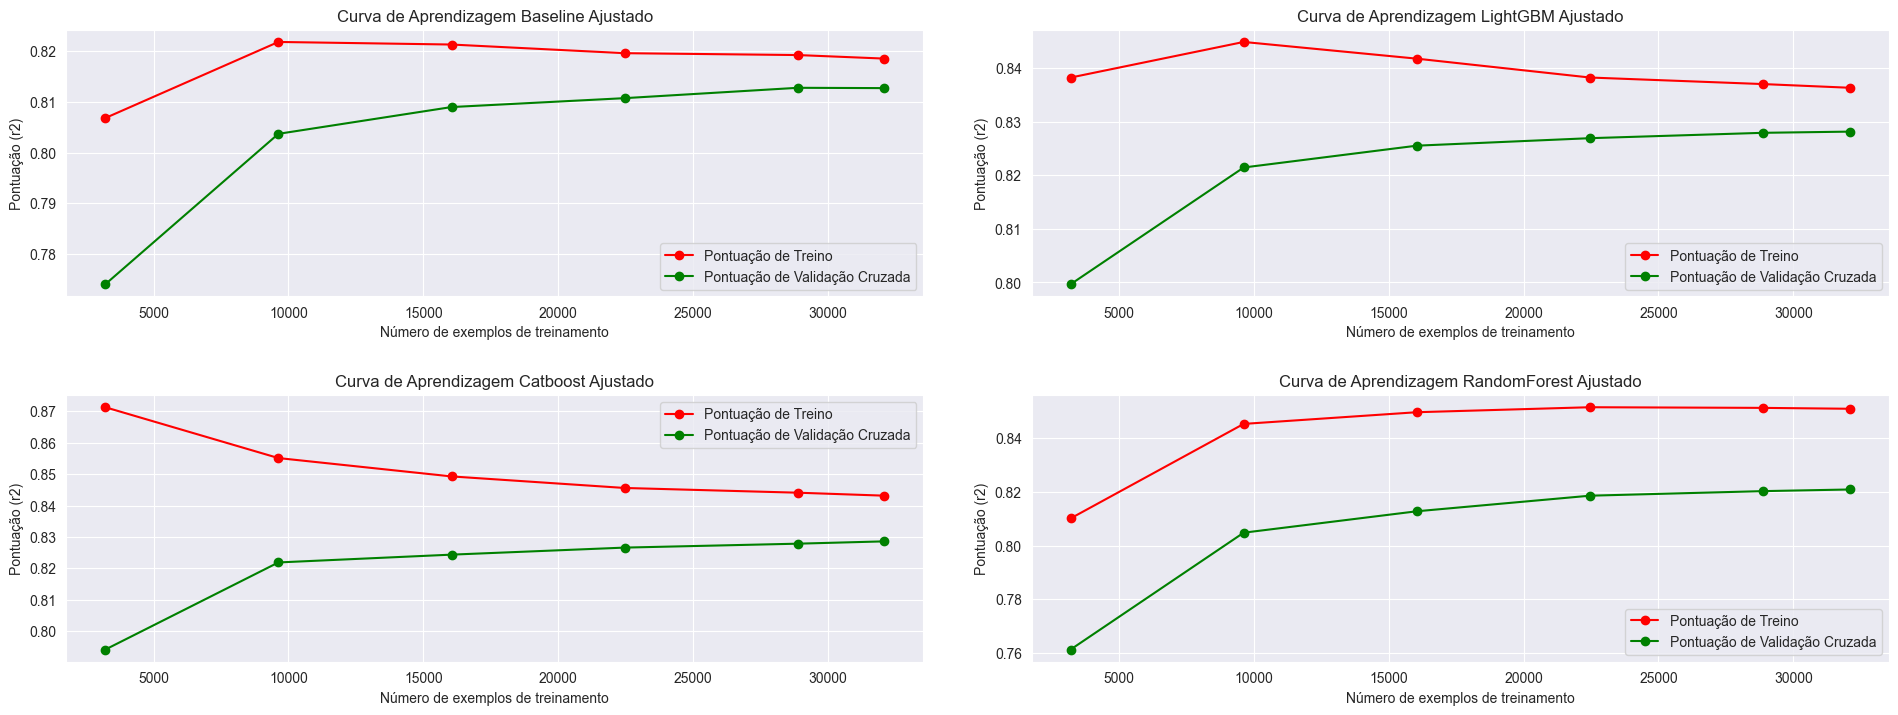

In [81]:
# comparação da melhoria de resultado do baseline com ajuste de hiper-paramâmetros
fig,ax = plt.subplots(2,2, figsize=(20,8))
plt.tight_layout(pad=5)
grafico_curva_aprendizagem(estimator=halving_baseline.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem Baseline Ajustado', ax=ax[0][0])
grafico_curva_aprendizagem(estimator=halving_lgbm.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem LightGBM Ajustado', ax=ax[0][1])
grafico_curva_aprendizagem(estimator=halving_cat.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem Catboost Ajustado', ax=ax[1][0])
grafico_curva_aprendizagem(estimator=halving_rf.best_estimator_,X=X, y=y, train_size=[0.1, 0.3, 0.5, 0.7, 0.9, 1.0],cv=KFold(n_splits=5), 
                           scoring='r2', titulo ='Curva de Aprendizagem RandomForest Ajustado', ax=ax[1][1])

fig.savefig('../reports/figures/models/comparativo_curva_aprendizagem.png')

In [82]:
# dataset de comparação dos resultados
lista_comparacao = [metricas_baseline_halving,metricas_lgbm_halving,metricas_cat_halving,metricas_rf_halving]

tbl_resultado = pd.DataFrame(lista_comparacao)
tbl_resultado.sort_values(by='R2_Teste',ascending=False)

,Modelo,R2_Teste,MAE_Teste,MSE_Teste,RMSE_Teste,R2_Treino,MAE_Treino,MSE_Treino,RMSE_Treino,Tempo_Treino_Segundos,Tempo_Predicao_Segundos,Hiperparametros
1,LightGBM_Halving,0.829041,0.149812,0.036931,0.192174,0.836208,0.147621,0.035788,0.189178,85.281059,0.035314,"{'model__subsample': 0.8, 'model__reg_lambda':..."
2,Catboost_Halving,0.828795,0.149850,0.036984,0.192312,0.841915,0.144718,0.034542,0.185854,2266.542617,0.029640,"{'model__learning_rate': 0.05, 'model__l2_leaf..."
3,RandomForest_Halving,0.822631,0.151641,0.038316,0.195744,0.850660,0.140314,0.032631,0.180640,148.985807,0.129622,"{'model__n_estimators': 140, 'model__min_sampl..."
0,Baseline_Halving_Arv_Decisao,0.814036,0.156258,0.040172,0.200430,0.818203,0.155204,0.039723,0.199305,27.144913,0.012035,"{'model__min_samples_split': 5, 'model__min_sa..."


In [ ]:
# modelo campeão em produção

tracking_uri = mlflow.get_tracking_uri()
print("O Mlflow Client se conectou ao seguinte endereço (Tracking URI):")
print(tracking_uri)
client = MlflowClient()
model_name = "LightGBM_Ajustado"
version_number = 7 
print(f"Tentando promover a Versão {version_number} de '{model_name}' para Production...")

try:
    
    client.transition_model_version_stage(
        name=model_name,
        version=version_number,
        stage="Production"
    )
    print(f"\nSUCESSO: A Versão {version_number} agora é o modelo oficial de Produção!")
    
except Exception as e:
    print(f"\nERRO: Não foi possível promover o modelo. Verifique a conexão DagsHub/MLflow.")
    print(f"Detalhes do Erro: {e}")

In [ ]:
# persistência do modelo
joblib.dump(halving_lgbm,'../src/models/lightgbm_ajustado.pkl')

# Winner

In [6]:
# importação do modelo em produção no mlflow
model_uri = "models:/LightGBM_Ajustado/Production"

try:
    loaded_model = load_pyfunc_model(model_uri)
    print("Modelo LightGBM carregado com sucesso usando o flavor pyfunc.")

except Exception as e:
    print(f"Erro ao carregar com pyfunc: {e}")

Modelo LightGBM carregado com sucesso usando o flavor pyfunc.


### Análise da Arvore de Regressão
O LightGBM não permite identificar as colunas usadas no nós de decisão.<br>
Podemos perceber que existe um equilíbrio em relação aos valores gerados nas decisões dos nós, juntamente com um nível de profundidade e nós de decisão controlados.

In [7]:
# seleção do modelo

pipeline_completo = loaded_model._model_impl.sklearn_model 
modelo_final = pipeline_completo.best_estimator_.named_steps['model']
preprocessor = pipeline_completo.best_estimator_.named_steps['preprocessing']

In [ ]:
# visualização da arvore 
features =  preprocessor.get_feature_names_out().tolist()
gerar_arvore(modelo=modelo_final, feature_list=features, model_type='lightgbm', filename='..reports/figures/arvore_lightgbm_prod')

In [85]:
# previsão do modelo
dados_novos = pd.DataFrame({
    'Agent_Age': [21],
    'Agent_Rating': [5.0],
    'Weather': ['Sunny'],
    'Vehicle': ['motorcyle'],
    'Area': ['Metropolitian'],
     'delivery_distance': [20.2], 
     'is_grocery': [0], 
     'jam_or_high_traffic': [0], 
     'dist_gte_10': [1]
    
})

try:
    # 1. Faz a previsão
    previsao = np.exp(loaded_model.predict(dados_novos))

    # 2. Exibe o resultado (o tempo de ciclo de entrega)
    print("\n--- Resultado da Inferência ---")
    print(f"Previsão do 'order_cicle_time': {previsao[0]:.2f} minutos")
    print("------------------------------")
    
except Exception as e:
    print(f"Erro ao fazer a previsão: {e}")


--- Resultado da Inferência ---
Previsão do 'order_cicle_time': 103.77 minutos
------------------------------


In [23]:
# dataset transformado para plotagem dos gráficos com valores shap e resíduos por categorias
X_teste_transformado = preprocessor.transform(X_teste)
feature_names = preprocessor.get_feature_names_out()

y_pred_transformado = pd.Series(y_pred_lbg_hlv_teste, name='y_pred', index=y_teste.index)

X_teste_transformado = pd.DataFrame(X_teste_transformado, columns=feature_names, index=X_teste.index)

X_teste_transformado['y_true'] = y_teste

X_teste_transformado = pd.concat([X_teste_transformado, y_pred_transformado], axis=1)
X_teste_transformado['res'] = X_teste_transformado['y_true'] - X_teste_transformado['y_pred']       

## Análise da Importância das Features
 O gráfico bar plot combinado com o beeswarm comprova a nossa validação de hipóteses para as features criadas na etapa de feature engineering.<br>
 `is_grocery`: feature de maior contribuição da média absoluta do `order_cicle_time`. Menores `order_cicle_time` apresentam essa flag.<br>
 `jam_or_hig_traffic` e `dit_gte_10` contribuem significamente para a média absoluta do `order_cicle_time`. Valores positivos impactam no aumento da média absoluta do `order_cicle_time`.<br>
 `Agent_Age` e `Agent_Rating` contribuem significamente para a média absoluta do `order_cicle_time`. Valores altos impactam de forma inversa no aumento da média absoluta do `order_cicle_time`. 

In [ ]:
# grafico de barra shap value para análise das fetures importances
gerar_grafico_shap(model= modelo_final, X_df= X_teste_transformado.drop(['y_true', 'y_pred', 'res'], axis=1).sample(n=300,random_state=42), kind='bar',path='../reports/figures/models/features_shap_value_bar_plot.png')

In [ ]:
# grafico beeswarm shap value para análise das fetures importances
gerar_grafico_shap(model= modelo_final, X_df= X_teste_transformado.drop(['y_true', 'y_pred', 'res'], axis=1).sample(n=300,random_state=42), 
                   kind='beeswarm', path='../reports/figures/models/features_shap_value_beeswarm_plot.png')

## Analise do Resíduo e definição de políticas
A dispersão dos resíduos valida uma política de intervenção para correção do  `order_cicle_time`, pois o modelo LightGBM demonstra uma tendência a subestimar (resíduos positivos) o tempo real de entrega nos cenários de alto valor previsto (zona de risco acima de 40 minutos). Este viés de otimismo é particularmente notável para entregas com distância acima de 10km, e em condições de jam_or_high_traffic. Portanto, a intervenção se torna crucial nessas categorias, garantindo que o modelo não leve a uma subestimação que resulte em atrasos.

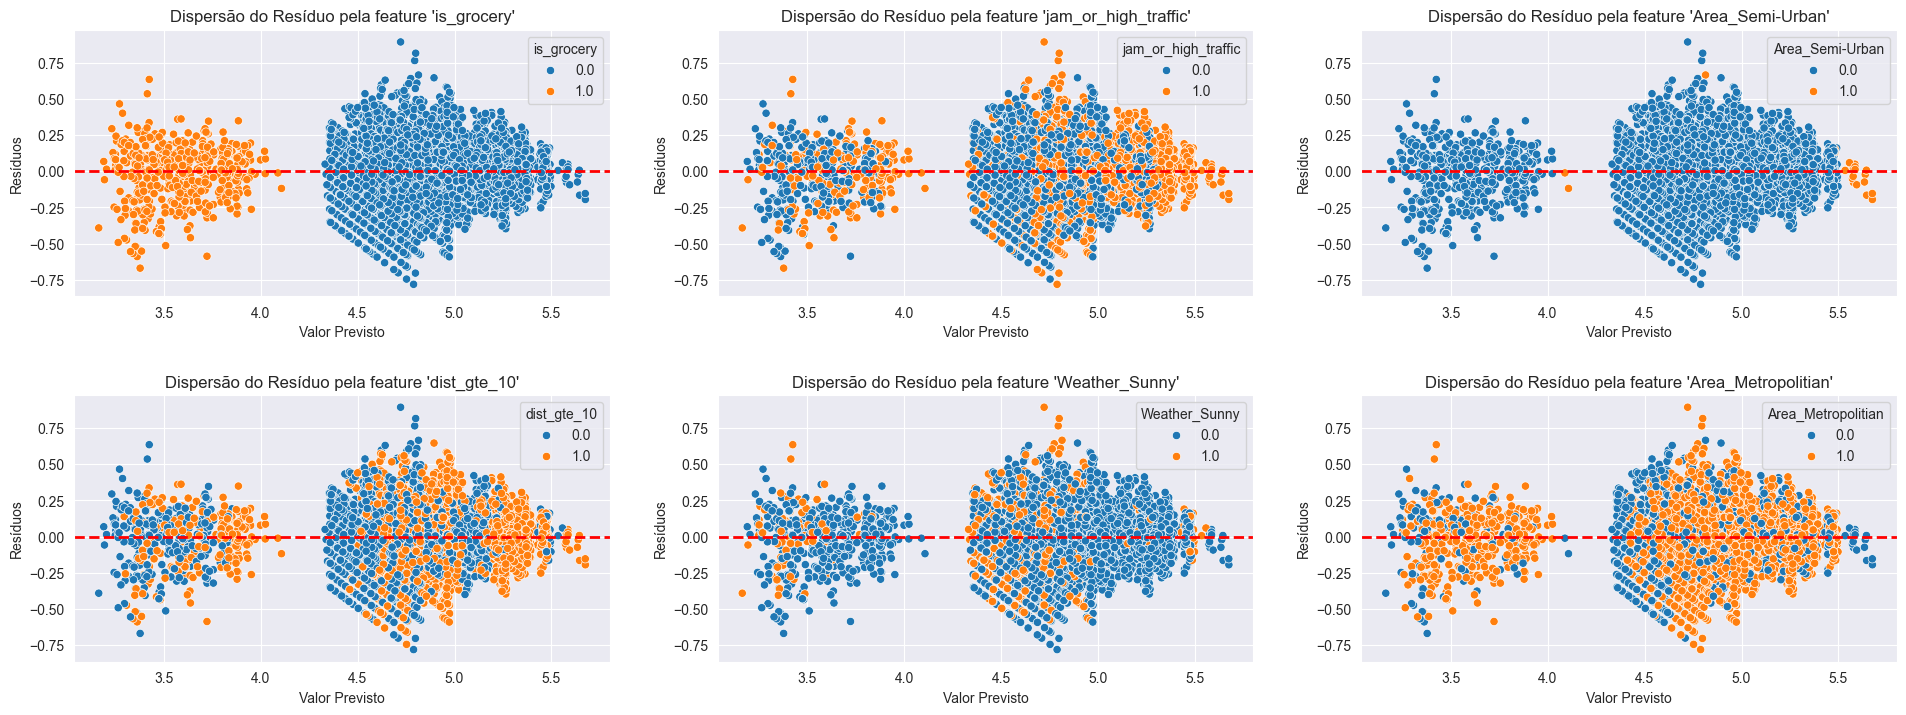

In [26]:
# comparação da melhoria de resultado do baseline com ajuste de hiper-paramâmetros
fig,ax = plt.subplots(2,3, figsize=(20,8))
plt.tight_layout(pad=5)
grafico_dispersao(df=X_teste_transformado, y=X_teste_transformado['res'],
                          x=X_teste_transformado['y_pred'],
                          titulo="Dispersão do Resíduo pela feature 'is_grocery'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'is_grocery', ax=ax[0][0])

grafico_dispersao(df=X_teste_transformado, y=X_teste_transformado['res'],
                          x=X_teste_transformado['y_pred'],
                          titulo="Dispersão do Resíduo pela feature 'jam_or_high_traffic'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'jam_or_high_traffic', ax=ax[0][1])

grafico_dispersao(df=X_teste_transformado, y=X_teste_transformado['res'],
                          x=X_teste_transformado['y_pred'],
                          titulo="Dispersão do Resíduo pela feature 'dist_gte_10'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'dist_gte_10', ax=ax[1][0])

grafico_dispersao(df=X_teste_transformado, y=X_teste_transformado['res'],
                          x=X_teste_transformado['y_pred'],
                          titulo="Dispersão do Resíduo pela feature 'Weather_Sunny'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'Weather_Sunny', ax=ax[1][1])
grafico_dispersao(df=X_teste_transformado, y=X_teste_transformado['res'],
                          x=X_teste_transformado['y_pred'],
                          titulo="Dispersão do Resíduo pela feature 'Area_Semi-Urban'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'Area_Semi-Urban', ax=ax[0][2])
grafico_dispersao(df=X_teste_transformado, y=X_teste_transformado['res'],
                          x=X_teste_transformado['y_pred'],
                          titulo="Dispersão do Resíduo pela feature 'Area_Metropolitian'", ylabel='Resíduos', xlabel='Valor Previsto', res=True, hue = 'Area_Metropolitian', ax=ax[1][2])

fig.savefig('../reports/figures/models/analise_residuo_features_categoricas.png')